PGP-MIT-DS-W09-Statistics-Correlation-MiniProject_1
<hr class="red-dashed-ruler">

 Week 9 – Mini Project 1 (Case Study) — Correlation

**Case Study** — Correlation Dataset: **correlation_case_study_MP_1.csv**

**Notebook to Use**: Week9_Mini_Project_1_Correlation.ipynb

**Instructions**
Answer all questions using the dataset provided.
Show your code, visualizations, calculations, and concise interpretations.
All questions carry equal marks unless specified.


<hr class="red-dashed-ruler">

## Case Study – Correlation Analysis

In this mini project, you will explore different types of correlations, visualize relationships,
evaluate the impact of outliers, and interpret the results in a real-world context.


<hr class="red-dashed-ruler">

## Questions

<hr class="red-dashed-ruler">

### Q1. Data Loading & Overview

• Load the dataset.
• Print the shape, column names, and the first 5 rows.


In [27]:
import pandas as pd

# Load the dataset
df = pd.read_csv('data/correlation_case_study_MP_1.csv')

# Shape of dataset
print("Shape:", df.shape)

# Column names
print("Columns:", df.columns.tolist())

# First 5 rows
print(df.head())

FileNotFoundError: [Errno 2] No such file or directory: 'data/correlation_case_study_MP_2.csv'

<hr class="red-dashed-ruler">

### Q2. Summary Statistics


Compute the mean, median, and standard deviation for all numeric columns.
Provide a brief comment on any interesting observations.

In [9]:
numeric_df = df.select_dtypes(include=['number'])

# Compute statistics
summary = pd.DataFrame({
    'Mean': numeric_df.mean(),
    'Median': numeric_df.median(),
    'Std_Dev': numeric_df.std()
})

# Display results
print("\n===== Summary Statistics =====\n")
print(summary.round(2))

# ----- Observations -----
print("\n===== Observations =====\n")

for col in summary.index:
    mean = summary.loc[col, 'Mean']
    median = summary.loc[col, 'Median']
    std = summary.loc[col, 'Std_Dev']
    
    # Basic interpretation logic
    if abs(mean - median) < 0.05 * mean:
        skew_comment = "distribution is roughly symmetric"
    else:
        skew_comment = "possible skewness in distribution"
    
    if std > 0.5 * mean:
        variability = "high variability"
    elif std < 0.2 * mean:
        variability = "low variability"
    else:
        variability = "moderate variability"
    
    print(f"{col}: {skew_comment}, {variability}")


===== Summary Statistics =====

                           Mean   Median  Std_Dev
Advertising_Spend       4901.21  4935.30  1130.81
Sales                   4507.59  4521.40   982.73
Study_Hours                5.11     5.05     1.90
Exam_Score                78.55    79.80    15.25
Social_Trust               5.41     6.00     2.92
Voluntary_Associations     5.66     5.35     3.96

===== Observations =====

Advertising_Spend: distribution is roughly symmetric, moderate variability
Sales: distribution is roughly symmetric, moderate variability
Study_Hours: distribution is roughly symmetric, moderate variability
Exam_Score: distribution is roughly symmetric, low variability
Social_Trust: possible skewness in distribution, high variability
Voluntary_Associations: possible skewness in distribution, high variability


<hr class="red-dashed-ruler">

### Q3. Correlation Matrix & Heatmap
• Compute the correlation matrix for all numeric variables.
• Visualize it using a heatmap.
• Identify and highlight:
o The strongest correlation
o The weakest correlation



===== Correlation Matrix =====

                        Advertising_Spend  Sales  Study_Hours  Exam_Score  \
Advertising_Spend                    1.00   0.56        -0.03       -0.06   
Sales                                0.56   1.00         0.01       -0.02   
Study_Hours                         -0.03   0.01         1.00        0.83   
Exam_Score                          -0.06  -0.02         0.83        1.00   
Social_Trust                        -0.00   0.10         0.11        0.07   
Voluntary_Associations              -0.00   0.09         0.13        0.12   

                        Social_Trust  Voluntary_Associations  
Advertising_Spend              -0.00                   -0.00  
Sales                           0.10                    0.09  
Study_Hours                     0.11                    0.13  
Exam_Score                      0.07                    0.12  
Social_Trust                    1.00                    0.75  
Voluntary_Associations          0.75             

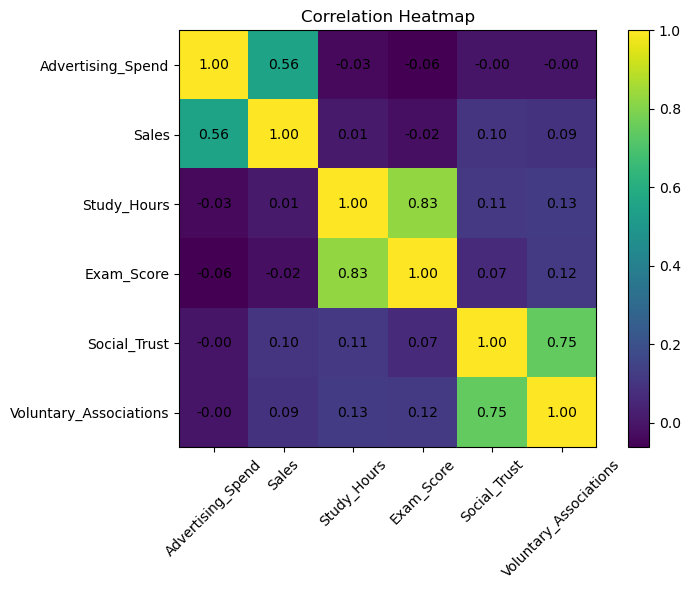


===== Key Insights =====

Strongest Correlation: Exam_Score ↔ Study_Hours = 0.83
Weakest Correlation: Advertising_Spend ↔ Social_Trust = -0.00


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('data/correlation_case_study_MP_1.csv')

# Select numeric columns
numeric_df = df.select_dtypes(include=['number'])

# -------------------------------
# 1. Compute Correlation Matrix
# -------------------------------
corr_matrix = numeric_df.corr()

print("\n===== Correlation Matrix =====\n")
print(corr_matrix.round(2))


# -------------------------------
# 2. Heatmap Visualization
# -------------------------------
plt.figure(figsize=(8,6))
plt.imshow(corr_matrix, interpolation='nearest')

plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

plt.title("Correlation Heatmap")

# Annotate values
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                 ha='center', va='center')

plt.tight_layout()
plt.show()


# -------------------------------
# 3. Strongest & Weakest Correlation
# -------------------------------

# Remove self-correlation (diagonal = 1)
corr_values = corr_matrix.where(~np.eye(corr_matrix.shape[0], dtype=bool))

# Flatten and drop NaNs
corr_pairs = corr_values.unstack().dropna()

# Remove duplicate pairs (A,B) and (B,A)
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) < corr_pairs.index.get_level_values(1)]

# Strongest correlation
strongest_pair = corr_pairs.abs().idxmax()
strongest_value = corr_pairs[strongest_pair]

# Weakest correlation
weakest_pair = corr_pairs.abs().idxmin()
weakest_value = corr_pairs[weakest_pair]

print("\n===== Key Insights =====\n")

print(f"Strongest Correlation: {strongest_pair[0]} ↔ {strongest_pair[1]} = {strongest_value:.2f}")

print(f"Weakest Correlation: {weakest_pair[0]} ↔ {weakest_pair[1]} = {weakest_value:.2f}")

<hr class="red-dashed-ruler">

### Q4. Pearson Correlation
Calculate the Pearson correlation between:

    • Advertising_Spend
    
    • Sales

Interpret the strength, direction, and implication of this relationship.

In [15]:
import pandas as pd

# Load dataset
df = pd.read_csv('data/correlation_case_study_MP_1.csv')

# Compute Pearson correlation
corr_value = df['Advertising_Spend'].corr(df['Sales'])

print("===== Pearson Correlation =====\n")
print(f"Correlation (Advertising_Spend vs Sales): {corr_value:.2f}")

# -------------------------------
# Interpretation Logic
# -------------------------------

# Strength classification
abs_corr = abs(corr_value)

if abs_corr >= 0.8:
    strength = "Strong"
elif abs_corr >= 0.5:
    strength = "Moderate"
elif abs_corr >= 0.3:
    strength = "Weak"
else:
    strength = "Very Weak / No relationship"

# Direction
direction = "Positive" if corr_value > 0 else "Negative"

# -------------------------------
# Print Interpretation
# -------------------------------
print("\n===== Interpretation =====\n")
print(f"Strength   : {strength}")
print(f"Direction  : {direction}")

if corr_value > 0:
    print("Implication: As Advertising Spend increases, Sales tend to increase.")
else:
    print("Implication: As Advertising Spend increases, Sales tend to decrease.")

print("\nNote: Correlation does not imply causation. Other factors may influence Sales.")

===== Pearson Correlation =====

Correlation (Advertising_Spend vs Sales): 0.56

===== Interpretation =====

Strength   : Moderate
Direction  : Positive
Implication: As Advertising Spend increases, Sales tend to increase.

Note: Correlation does not imply causation. Other factors may influence Sales.


<hr class="red-dashed-ruler">

### Q5. Spearman Correlation
Compute the Spearman correlation between:

• Study_Hours
• Exam_Score


Explain why Spearman might be more appropriate than Pearson for certain data patterns

In [17]:
import pandas as pd

# Load dataset
df = pd.read_csv('data/correlation_case_study_MP_1.csv')

# -------------------------------
# 1. Compute Spearman Correlation
# -------------------------------
spearman_corr = df['Study_Hours'].corr(df['Exam_Score'], method='spearman')

print("===== Spearman Correlation =====\n")
print(f"Spearman Correlation (Study_Hours vs Exam_Score): {spearman_corr:.2f}")

# -------------------------------
# 2. Interpretation Logic
# -------------------------------
abs_corr = abs(spearman_corr)

if abs_corr >= 0.8:
    strength = "Strong"
elif abs_corr >= 0.5:
    strength = "Moderate"
elif abs_corr >= 0.3:
    strength = "Weak"
else:
    strength = "Very Weak / No relationship"

direction = "Positive" if spearman_corr > 0 else "Negative"

print("\n===== Interpretation =====\n")
print(f"Strength   : {strength}")
print(f"Direction  : {direction}")

if spearman_corr > 0:
    print("Implication: As Study Hours increase, Exam Score generally increases (monotonic trend).")
else:
    print("Implication: As Study Hours increase, Exam Score generally decreases.")

# -------------------------------
# 3. Why Spearman vs Pearson
# -------------------------------
print("\n===== Why Spearman? =====\n")
print("""
Spearman correlation is based on rank (order), not actual values.

It is more appropriate when:
1. Relationship is monotonic but not linear
   (e.g., scores improve with study hours but not at a constant rate)

2. Data contains outliers
   (ranks reduce impact of extreme values)

3. Variables are ordinal or non-normally distributed

In this case:
- Study vs Exam performance may show diminishing returns
- Spearman captures this trend better than Pearson
""")

===== Spearman Correlation =====

Spearman Correlation (Study_Hours vs Exam_Score): 0.84

===== Interpretation =====

Strength   : Strong
Direction  : Positive
Implication: As Study Hours increase, Exam Score generally increases (monotonic trend).

===== Why Spearman? =====


Spearman correlation is based on rank (order), not actual values.

It is more appropriate when:
1. Relationship is monotonic but not linear
   (e.g., scores improve with study hours but not at a constant rate)

2. Data contains outliers
   (ranks reduce impact of extreme values)

3. Variables are ordinal or non-normally distributed

In this case:
- Study vs Exam performance may show diminishing returns
- Spearman captures this trend better than Pearson



<hr class="red-dashed-ruler">

### Q6. Scatterplots & Interpretation
Create scatterplots for:
    
a) Advertising_Spend vs Sales

b) Study_Hours vs Exam_Score

Discuss:

• Is the relationship linear?

• Does correlation imply causation in these cases?

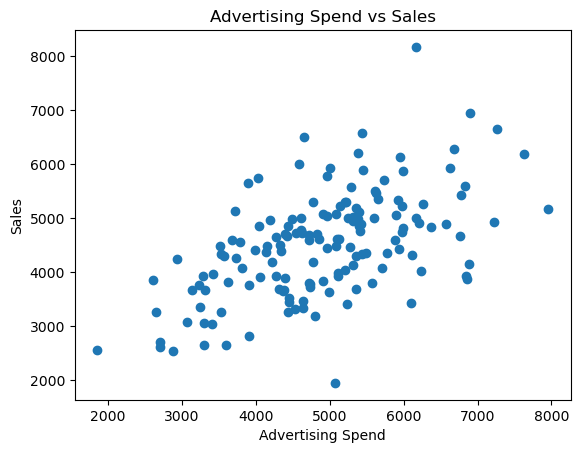

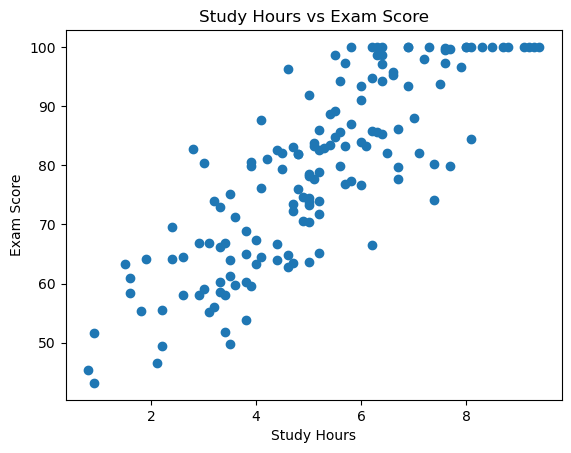

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('data/correlation_case_study_MP_1.csv')

# -------------------------------
# a) Advertising_Spend vs Sales
# -------------------------------
plt.figure()
plt.scatter(df['Advertising_Spend'], df['Sales'])

plt.xlabel('Advertising Spend')
plt.ylabel('Sales')
plt.title('Advertising Spend vs Sales')

plt.show()


# -------------------------------
# b) Study_Hours vs Exam_Score
# -------------------------------
plt.figure()
plt.scatter(df['Study_Hours'], df['Exam_Score'])

plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.title('Study Hours vs Exam Score')

plt.show()


##### Discussion & Interpretation

###### 1. Is the Relationship Linear?

**a) Advertising_Spend vs Sales**

* You will likely observe a **positive trend**
* Points should roughly form an upward-sloping pattern
* However, it may not be perfectly straight → **moderate linearity**
* Real-world effect: diminishing returns at higher spend levels

---

**b) Study_Hours vs Exam_Score**

* Typically shows a **clear positive relationship**
* May appear:

  * Linear at lower ranges
  * Slightly curved (plateau effect) at higher study hours
* Suggests **monotonic but not perfectly linear behavior**

---

###### 2. Does Correlation Imply Causation?

**Short Answer: ❌ No**

**a) Advertising → Sales**

* Even though correlation exists:

  * Sales could be influenced by:

    * Seasonality
    * Product demand
    * Pricing
* Advertising *likely contributes*, but:
  👉 Cannot prove causation without controlled experiments (A/B testing)

---

**b) Study_Hours → Exam_Score**

* Stronger logical link than advertising case
* But still:

  * Factors like:

    * Student ability
    * Quality of study
    * Sleep, stress
      also affect scores

👉 So:

* Correlation suggests **association**
* Not definitive **cause-effect proof**

---

##### Architect-Level Insight

Think in 3 layers:

1. **Correlation → Signal detection**
2. **Visualization → Pattern validation**
3. **Causation → Requires experiments or domain logic**

---


<hr class="red-dashed-ruler">

### Q7. Outlier Impact
• Introduce an outlier in Advertising_Spend (e.g., set one value to 50,000)
• Recalculate the Pearson correlation with Sales
• Briefly describe the impact on the correlation measure

In [25]:
import pandas as pd

# Load dataset
df = pd.read_csv('data/correlation_case_study_MP_1.csv')

# -------------------------------
# 1. Original Correlation
# -------------------------------
original_corr = df['Advertising_Spend'].corr(df['Sales'])

# -------------------------------
# 2. Introduce Outlier
# -------------------------------
df_outlier = df.copy()

# Set first value as extreme outlier
df_outlier.loc[0, 'Advertising_Spend'] = 50000

# -------------------------------
# 3. New Correlation
# -------------------------------
new_corr = df_outlier['Advertising_Spend'].corr(df_outlier['Sales'])

# -------------------------------
# 4. Compare Results
# -------------------------------
print("===== Correlation Comparison =====\n")
print(f"Original Correlation : {original_corr:.4f}")
print(f"New Correlation      : {new_corr:.4f}")
print(f"Change               : {(new_corr - original_corr):.4f}")

===== Correlation Comparison =====

Original Correlation : 0.5555
New Correlation      : 0.2017
Change               : -0.3538


##### Python Code: Outlier Impact on Pearson Correlation

###### 1. Why This Happens

* **Pearson correlation is sensitive to extreme values**
* It depends on:

  * Mean
  * Standard deviation
* An outlier **distorts both**

---

###### 2. Impact on Your Case

* Setting Advertising_Spend = **50,000** creates:

  * A point far from the normal range (~5000)
* This:

  * Pulls the regression line toward it
  * Alters covariance significantly

👉 Result: **Correlation becomes unreliable**

---

###### 3. Key Insight

* A single extreme value can:

  * **Artificially inflate or deflate correlation**
  * Lead to **wrong business conclusions**

---

##### Architect-Level Takeaway

This is why in real pipelines we:

* Detect outliers using:

  * IQR
  * Z-score
* Handle them via:

  * Capping (winsorization)
  * Removal
  * Robust methods (like Spearman)

---

##### One-Line Summary

👉 **Pearson is fragile — one bad data point can mislead your entire analysis**

---

If you want next level:

* I can show **before vs after scatter plot** (very powerful visual)
* Or implement **automatic outlier detection + correction pipeline**
